## Synthetic Explorer

This notebook will produce a set of graphs showing the average data distribution of the synthetic data. We are interested in data distribution to check the differences between the average consensus when the parameter we are varying is low, and when the parameter is high. This may explain any ponential issues we face (such as not seeing obvious trends)

In [58]:
# imports
import pandas as pd
import os
import fnmatch
import glob
import copy
from data_analysis.plot_fairness import *

# Dirs
exps = ["vary_grp_fact", "vary_mup_vamu", "vary_pvs_prip"]
agents_pvs_dir = "/Users/josephtrevorrow/Documents/GitHub/HCVA-plus-plus/value_systems/Synthetic/" + exps[1] + "/PVS/"
agents_prip_dir = "/Users/josephtrevorrow/Documents/GitHub/HCVA-plus-plus/value_systems/Synthetic/" + exps[1] + "/PriP/"

dir_dict = {}
## iterate over every output_dir (100)
for dir in range(0,100):
    count = len(fnmatch.filter(os.listdir(agents_pvs_dir+str(dir)+"/"),"*.csv"))
    ## STEP 1: READ IN THE DATA
    ## input every single agent, place in a list of df (form: [t1_agents, t2_agents, etc.
    agents_list = []
    ## Grab the agents PVS and concat them
    ag_pvs = glob.glob(agents_pvs_dir + str(dir)+"/"+"*PVS*")
    ag_prip = glob.glob(agents_prip_dir + str(dir)+"/"+"*PriP*")
    sorted_ag_pvs = sorted(ag_pvs)
    sorted_ag_prip = sorted(ag_prip)
    #print("sorted_ag_pvs: ", [os.path.basename(temp) for temp in sorted_ag_pvs])
    #print("sorted_ag_prip: ", [os.path.basename(temp) for temp in sorted_ag_prip])
    # TODO: THIS SORTS 0.67 BEFORE 0.6_! (doesn't neccessarily matter in this case)

    for i in range(0, count):
        agents_pvs_df = pd.read_csv(sorted_ag_pvs[i])
        agents_prip_df = pd.read_csv(sorted_ag_prip[i])
        agents_df = pd.concat([agents_pvs_df, agents_prip_df], axis=1, join="inner")
        agents_list.append(copy.deepcopy(agents_df))

    #print("________________________________")
    #print("AGENTS_LIST: ", agents_list, "")
    values_list = list([col for col in agents_list[0].columns if 'P__' in col])
    cleaned_values_list = copy.deepcopy(values_list)
    # Clean list_of_params
    # Remove all cols that have the same two values (P__Universalism__Universalism, P__Benevolence__Benevolence, etc.)
    for col in values_list:
        col_split = col.split("__")
        if len(col_split) == 3 and col_split[1] == col_split[2]:
            cleaned_values_list.remove(col)
        elif col in cleaned_values_list:
            # Not dropped, so drop the symmetrical col (P__A__B == P__B__A)
            symmetrical_col = "P__" + col_split[2] + "__" + col_split[1]
            if symmetrical_col in cleaned_values_list:
                cleaned_values_list.remove(symmetrical_col)
    print("cleaned values list: ", cleaned_values_list, "")

    actions_list = list([col for col in agents_list[0].columns if 'VA__' in col])
    agents_cols_to_keep = cleaned_values_list + actions_list + ["Egalitarian"]

    for i in range(0, len(agents_list)):
        agents_list[i] = agents_list[i][agents_cols_to_keep]
    normalised_agents_df = normalise_agents_time_series(agents_list)
    dir_dict[dir] = [normalised_agents_df]

# Step 1: Create a dict `lines`, where we will store points for each timestep
lines = {}
count = len(fnmatch.filter(os.listdir(agents_pvs_dir+"/0/"),"*.csv"))
for i in range (0,count):
    lines[i] = []

################################
list_of_params = [cleaned_values_list[3], cleaned_values_list[4], cleaned_values_list[5]]
#################################

cleaned values list:  ['P__0__1', 'P__0__2', 'P__0__3', 'P__1__2', 'P__1__3', 'P__2__3'] 
cleaned values list:  ['P__0__1', 'P__0__2', 'P__0__3', 'P__1__2', 'P__1__3', 'P__2__3'] 
cleaned values list:  ['P__0__1', 'P__0__2', 'P__0__3', 'P__1__2', 'P__1__3', 'P__2__3'] 
cleaned values list:  ['P__0__1', 'P__0__2', 'P__0__3', 'P__1__2', 'P__1__3', 'P__2__3'] 
cleaned values list:  ['P__0__1', 'P__0__2', 'P__0__3', 'P__1__2', 'P__1__3', 'P__2__3'] 
cleaned values list:  ['P__0__1', 'P__0__2', 'P__0__3', 'P__1__2', 'P__1__3', 'P__2__3'] 
cleaned values list:  ['P__0__1', 'P__0__2', 'P__0__3', 'P__1__2', 'P__1__3', 'P__2__3'] 
cleaned values list:  ['P__0__1', 'P__0__2', 'P__0__3', 'P__1__2', 'P__1__3', 'P__2__3'] 
cleaned values list:  ['P__0__1', 'P__0__2', 'P__0__3', 'P__1__2', 'P__1__3', 'P__2__3'] 
cleaned values list:  ['P__0__1', 'P__0__2', 'P__0__3', 'P__1__2', 'P__1__3', 'P__2__3'] 
cleaned values list:  ['P__0__1', 'P__0__2', 'P__0__3', 'P__1__2', 'P__1__3', 'P__2__3'] 
cleaned va

In [59]:
# Step 2: Iterate over every timestep (each [normalised_cons_sets, normalised_agents_df] in dir_dict)
#   find the residuals for each of the cons, for each timestep, and add to lines
for iteration, data in dir_dict.items():
    # Unpack
    normalised_agents_df = data[0]
    # Do what we normally do with a single timestep:
    for i, agents_single in enumerate(normalised_agents_df):
        # find the residuals for each of the cons in cons_dict_single
        # For every consensus, go through each agent, and find difference.
        for agent in agents_single.iterrows():
            temp_sum_of_params = np.abs(agent[1][list_of_params].to_numpy().sum())
            # Update for this timestep
            lines[i].append(temp_sum_of_params)

Text(0.5, 1.0, 'lines[5]')

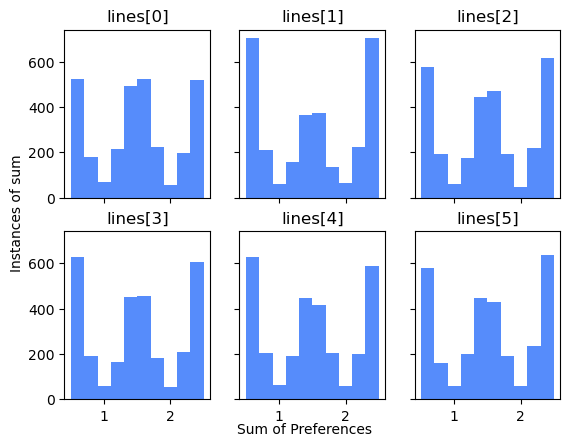

In [60]:
# plot
fig, axs = plt.subplots(2, 3, sharex=True, sharey=True,)

# Labels
fig.text(0.5, 0.04, 'Sum of Preferences', ha='center')
fig.text(0.04, 0.5, 'Instances of sum', va='center', rotation='vertical')

axs[0, 0].hist(lines[0])
# Below seems to set common xticks and xticklabels
axs[0, 0].set_title("lines[0]")

axs[0, 1].hist(lines[1])
# Below seems to set common xticks and xticklabels
axs[0, 1].set_title("lines[1]")

axs[0, 2].hist(lines[2])
# Below seems to set common xticks and xticklabels
axs[0, 2].set_title("lines[2]")

axs[1, 0].hist(lines[3])
# Below seems to set common xticks and xticklabels
axs[1, 0].set_title("lines[3]")

axs[1, 1].hist(lines[4])
# Below seems to set common xticks and xticklabels
axs[1, 1].set_title("lines[4]")

axs[1, 2].hist(lines[5])
# Below seems to set common xticks and xticklabels
axs[1, 2].set_title("lines[5]")

In [61]:
# Save to a file?
"""
output_dir = "/Users/josephtrevorrow/Documents/GitHub/HCVA-plus-plus/plots/" + dir
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print("Created directory: " + output_dir)
else:
    print("Directory already exists: " + output_dir)
fig.savefig(output_dir+title+".png", bbox_inches="tight")
# Save list_of_points to a file
with open(output_dir+title+"residuals.csv", 'w') as f:
    writer = csv.writer(f)
    writer.writerow(["key", "points"])
    for key, points in lines.items():
        row = [key] + points
        writer.writerow(row)
"""

'\noutput_dir = "/Users/josephtrevorrow/Documents/GitHub/HCVA-plus-plus/plots/" + dir\nif not os.path.exists(output_dir):\n    os.makedirs(output_dir)\n    print("Created directory: " + output_dir)\nelse:\n    print("Directory already exists: " + output_dir)\nfig.savefig(output_dir+title+".png", bbox_inches="tight")\n# Save list_of_points to a file\nwith open(output_dir+title+"residuals.csv", \'w\') as f:\n    writer = csv.writer(f)\n    writer.writerow(["key", "points"])\n    for key, points in lines.items():\n        row = [key] + points\n        writer.writerow(row)\n'